In [ ]:
# 1. Download the inference results if not already downloaded.

!wget "https://surfdrive.surf.nl/files/index.php/s/G8XWW8On5MWhtCk/download?path=%2FInference&files=inference_results_ToyExample-v2_Cologne-v1_CologneBonnDusseldorf-v1.csv" -qO inference_results.csv

# 2. Model checkpoints should be in ../outputs/Cologne-v1/vdn_rnn/

In [ ]:
import yaml
import jax
import jaxmarl

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from rollout_data_generator import RolloutDataGenerator
from heuristic_rollout_data_generator import HeuristicRolloutDataGenerator
from plotter import RolloutPlotter, plot_action_stats

## MARL agent

In [ ]:
ENV_NAME = 'Cologne-v1'
ALG = 'vdn_rnn'
env = jaxmarl.make("road_env", map_name=ENV_NAME)
rdg = RolloutDataGenerator(ENV_NAME, ALG, test_num_envs=1_000)
rp = RolloutPlotter(env)

key = jax.random.PRNGKey(87)
episode_data = rdg.generate_rollout_data(key, verbose=True)

## Heuristic

In [ ]:
config_path = "../experiments/config/heuristics/best_parameters/cologne_v1_heuristic.yaml"
config = yaml.safe_load(open(config_path, 'r'))
env = jaxmarl.make("road_env", map_name=config['map'])

rdg = HeuristicRolloutDataGenerator(config)
rp = RolloutPlotter(env)
key = jax.random.PRNGKey(87)
num_rollouts = 1000
episode_data = rdg.generate_rollout_data(key, num_rollouts, verbose=True)

action                              (1000, 50, 60)
applied_actions                     (1000, 50, 60)
budget_constraints_applied          (1000, 50)
budget_remaining                    (1000, 51)
edge_beliefs                        (1000, 51, 60, 5)
edge_observations                   (1000, 51, 60)
edge_states                         (1000, 51, 60)
episode_cost                        (1000, 1)
forced_repair_flags                 (1000, 50, 60)
forced_replace_constraint_applied   (1000, 50)
maintenance_reward                  (1000, 50)
reward                              (1000, 50)
terminal_reward                     (1000, 50)
timesteps                           (1000, 51)
total_travel_time                   (1000, 50)
traffic_volumes                     (1000, 50, 60)
travel_time_reward                  (1000, 50)
travel_times                        (1000, 50, 60)


## Analysing Multiple Episodes

### What is the distribution of returns across episodes?


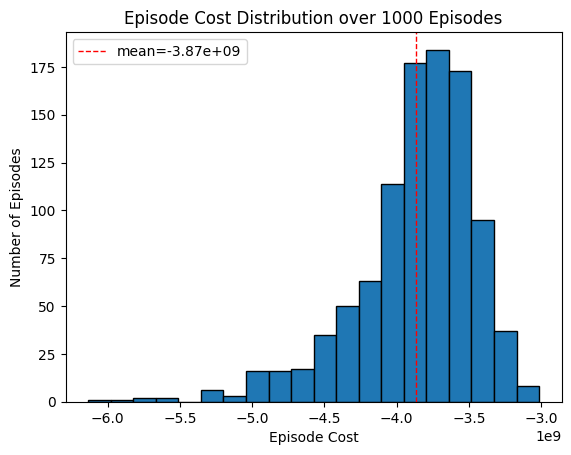

In [3]:
plt.hist(episode_data['episode_cost'].flatten(), edgecolor='black', bins=20)
_mean = np.mean(episode_data['episode_cost'])
plt.axvline(_mean, label=f'mean={_mean:.2e}', color='red', linestyle='dashed', linewidth=1)
plt.xlabel('Episode Cost')
plt.ylabel('Number of Episodes')
plt.title(f'Episode Cost Distribution over {episode_data["episode_cost"].shape[0]} Episodes')
plt.legend()
plt.show()

#### How often are budget constraints applied at timestep t?
#### How often are forced replacement actions applied at timestep t?

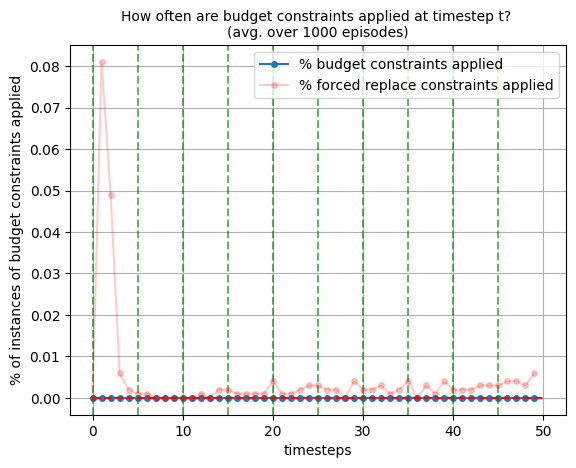

In [4]:
plt.plot(episode_data['budget_constraints_applied'].astype(int).mean(axis=0), '-o', markersize=4, label='% budget constraints applied')
plt.hlines(0, xmin=0, xmax=50, colors='red', linestyles='dashed')

for t in range(episode_data['budget_constraints_applied'].shape[1]):
    if t % 5 == 0:
        plt.axvline(t, color="green", linestyle="--", alpha=0.6)

plt.plot(episode_data['forced_replace_constraint_applied'].astype(int).mean(axis=0), '-o', markersize=4, color='red', alpha=0.2, label='% forced replace constraints applied')

plt.xlabel('timesteps')
plt.ylabel('% of instances of budget constraints applied')
plt.title(f'How often are budget constraints applied at timestep t? \n(avg. over {episode_data["budget_constraints_applied"].shape[0]} episodes)', fontsize=10)
plt.legend()
plt.grid()
plt.show()

#### What is the average distribution of `applied_actions` per period?

In [160]:
batched_get_rewards = jax.jit(
    jax.vmap(                                  # over episodes B
        jax.vmap(                              # over timesteps T
            env.env._get_rewards_from_table,   # already vmaps over C
            in_axes=(0, 0, 0, None),           # dam, act, forced, seg_len
        ),
        in_axes=(0, 0, 0, None),
    )
)

period = env.env.budget_renewal_interval
horizon = env.env.max_timesteps
period_stats = {
    key: []
    for key in [
        *(f"action{i}_per_period" for i in range(5)),
        *(f"action{i}_cost_per_period" for i in range(5)),
    ]
}

l = 0
for m in range(period, horizon + period, period):
    # applied_actions     | shape: (1000, 50, 60)
    # edge_states         | shape: (1000, 50, 60)
    # forced_repair_flags | shape: (1000, 50, 60)

    for a in range(5):

        action_mask = episode_data['applied_actions'][:, l:m, :] == a

        # number of actions per period
        num_actions = np.mean(action_mask)
        period_stats[f'action{a}_per_period'].append(num_actions)

        # cost per period
        # set all other actions to 0
        actions = episode_data['applied_actions'][:, l:m, :] * action_mask.astype(int)
        # compute rewards only for the selected actions
        _rewards = batched_get_rewards(episode_data['edge_states'][:, l:m, :], 
                                actions, 
                                episode_data['forced_repair_flags'][:, l:m, :], 
                                env.env.segment_lengths)
        # since action 0 has non-zero reward for doing nothing, we mask the rewards
        _rewards *= action_mask.astype(float)
        _rewards = _rewards.sum(axis=(1,2)).mean(axis=0)
        period_stats[f'action{a}_cost_per_period'].append(_rewards)

    l += period

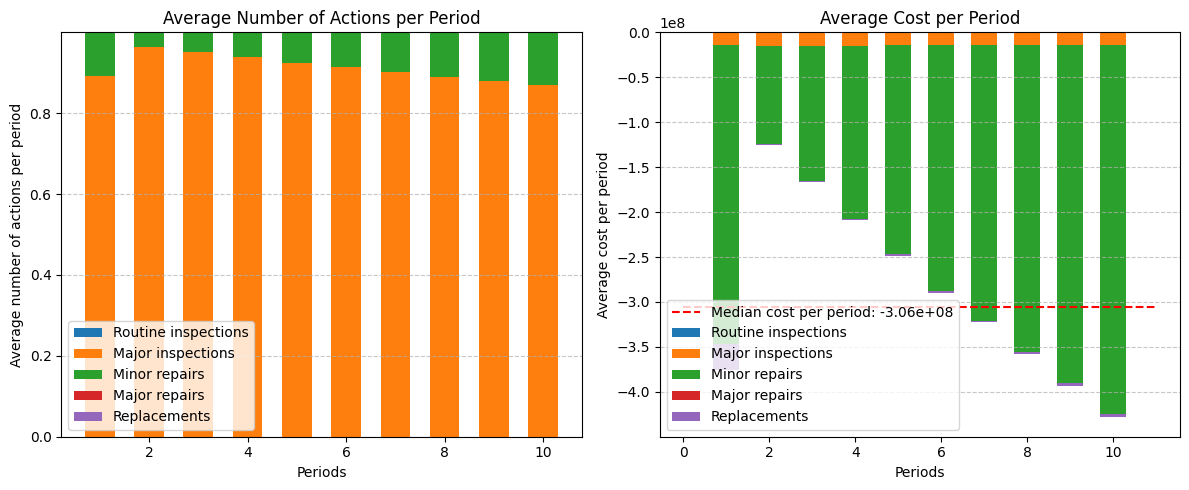

In [161]:
fix, ax = plt.subplots(1, 2, figsize=(12, 5))

labels = [
    "Routine inspections",
    "Major inspections",
    "Minor repairs",
    "Major repairs",
    "Replacements",
]

############# Avg. number of actions per period #############
series = [np.array(period_stats[f"action{i}_per_period"]) for i in range(5)]

# X axis (periods)
_periods = np.arange(1, len(series[0]) + 1)
bar_width = 0.6

# Stacked bars
bottom = np.zeros_like(series[0], dtype=float)
for y, lab in zip(series, labels):
    ax[0].bar(_periods, y, width=bar_width, bottom=bottom, label=lab)
    bottom += y

ax[0].set_xlabel("Periods")
ax[0].set_ylabel("Average number of actions per period")
ax[0].set_title("Average Number of Actions per Period")
ax[0].grid(axis="y", linestyle="--", alpha=0.7)
ax[0].legend()

############# Avg. cost per period #############
series = [np.array(period_stats[f"action{i}_cost_per_period"]) for i in range(5)]

# Stacked bars
bottom = np.zeros_like(series[0], dtype=float)
for y, lab in zip(series, labels):
    ax[1].bar(_periods, y, width=bar_width, bottom=bottom, label=lab)
    bottom += y

# === Median line across total cycle costs ===
cycle_costs = np.stack(series, axis=1).sum(axis=1)
median = np.median(cycle_costs)

ax[1].hlines(
    median,
    xmin=0,
    xmax=len(_periods) + 1,
    colors="red",
    linestyles="dashed",
    label=f"Median cost per period: {median:.2e}",
)

ax[1].set_xlabel("Periods")
ax[1].set_ylabel("Average cost per period")
ax[1].set_title("Average Cost per Period")
ax[1].grid(axis="y", linestyle="--", alpha=0.7)
ax[1].legend()

plt.tight_layout()
plt.show()

In [149]:
def round_to_nearest_multiple(x, base=5):
    """
    Rounds a number x to the nearest multiple of 'base' * 10^scale,
    where scale is chosen from the order of magnitude of x.
    """

    # get order of magnitude (10^n)
    scale = int(np.floor(np.log10(abs(x))))
    # keep one significant digit before rounding
    factor = 10 ** (scale - 1)

    # convert to base units of roughly correct scale
    return round(x / (base * factor)) * (base * factor)

cycle_costs = np.stack([np.array(period_stats[f"action{i}_cost_per_period"]) for i in range(5)]).sum(axis=0)
quantile_levels = [0.25, 0.5, 0.75, 0.95]
_budget_amounts = np.quantile(cycle_costs, quantile_levels, axis=0)
budget_amounts = []
for i, (q, t) in enumerate(zip(quantile_levels, ['easy', 'medium', 'hard', 'super hard'])):
    amount = -_budget_amounts[i]  # make positive
    rounded = round_to_nearest_multiple(amount)
    budget_amounts.append(rounded)
    print(f"{t:<10} ({int(q*100):>2}th percentile) | budget amount: {amount/1e6:.2f}M (~{rounded/1e6:.2f}M) ")

easy       (25th percentile) | budget amount: 371.28M (~350.00M) 
medium     (50th percentile) | budget amount: 305.86M (~300.00M) 
hard       (75th percentile) | budget amount: 218.54M (~200.00M) 
super hard (95th percentile) | budget amount: 143.74M (~150.00M) 


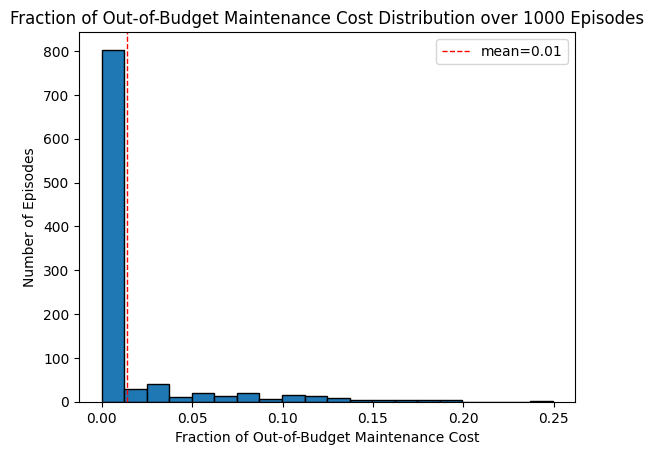

In [10]:
batched_get_rewards = jax.jit(
    jax.vmap(                                  # over episodes B
        jax.vmap(                              # over timesteps T
            env.env._get_rewards_from_table,   # already vmaps over C
            in_axes=(0, 0, 0, None),           # dam, act, forced, seg_len
        ),
        in_axes=(0, 0, 0, None),
    )
)

forced_repairs_cost = batched_get_rewards(episode_data['edge_states'][:, :-1, :], 
                              episode_data['applied_actions'], 
                              episode_data['forced_repair_flags'], 
                              env.env.segment_lengths) * episode_data['forced_repair_flags']

budgeted_maintenance_cost = batched_get_rewards(episode_data['edge_states'][:, :-1, :], 
                              episode_data['applied_actions'], 
                              episode_data['forced_repair_flags'], 
                              env.env.segment_lengths) * (~episode_data['forced_repair_flags'])

out_of_budget_cost = forced_repairs_cost.sum(axis=(1,2))
budgeted_cost = budgeted_maintenance_cost.sum(axis=(1,2))
frac_out_of_budget = out_of_budget_cost / (out_of_budget_cost + budgeted_cost)
plt.hist(frac_out_of_budget, edgecolor='black', bins=20)
_mean = np.mean(frac_out_of_budget)
plt.axvline(_mean, label=f'mean={_mean:.2f}', color='red', linestyle='dashed', linewidth=1)
plt.xlabel('Fraction of Out-of-Budget Maintenance Cost')
plt.ylabel('Number of Episodes')
plt.title(f'Fraction of Out-of-Budget Maintenance Cost Distribution over {episode_data["episode_cost"].shape[0]} Episodes')
plt.legend()
plt.show()

### Action Histograms

In [ ]:
save_fig_kwargs = None

plot_action_stats(episode_data['applied_actions'][:1000], save_kwargs=save_fig_kwargs)

## Analysing Single Episodes

In [15]:
# get data for a single episode among all the episode_data
single_episdode_data = rdg.get_single_episode_data(episode_data, episode_idx=34)

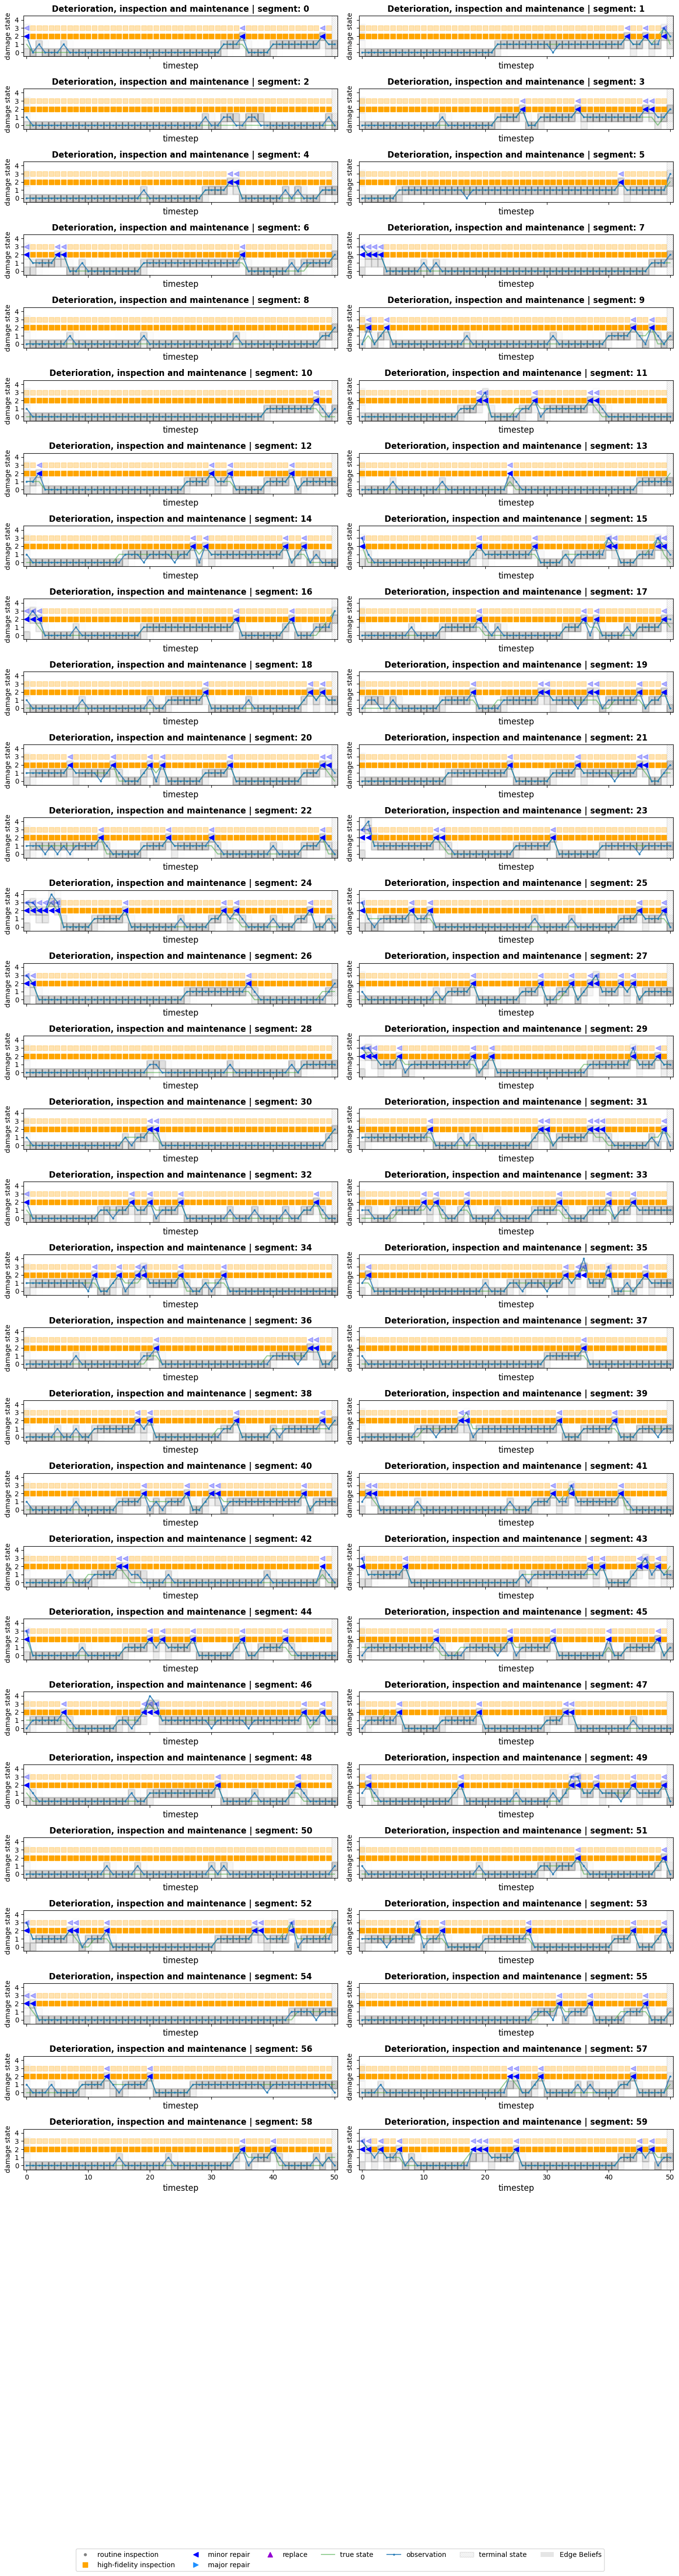

In [16]:
save_fig_kwargs = {
    "fname": "./rollout.pdf",
    "dpi": 300,
    "bbox_inches": "tight",
}
save_fig_kwargs = None

rp._plot_deterioration(single_episdode_data, save_kwargs=save_fig_kwargs)

In [ ]:
rp._plot_budget(single_episdode_data)

In [ ]:
rp._plot_travel_time_and_rewards(single_episdode_data)

In [ ]:
# ToDo: return travel times and traffic volumes in info from jax env
rp._plot_traffic_volume_and_travel_times(single_episdode_data, components_to_show='all')